In [1]:
generator_path = "/kaggle/input/braingan/generator_epoch_9000.h5"
discriminator_path = "/kaggle/input/braingan/discriminator_epoch_9000.h5"
dataset_path = "/kaggle/input/brain-tumor-mri-dataset/Testing"
test_data_path = dataset_path = "/kaggle/input/brain-tumor-mri-dataset/Testing"

In [2]:
import tensorflow as tf
import numpy as np
import cv2
from pathlib import Path
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

class HybridTumorDetector:
    def __init__(self, generator=None, discriminator=None, latent_dim=100):
        """
        Initialize the hybrid tumor detector with both GAN and CNN components
        """
        self.latent_dim = latent_dim
        self.scaler = StandardScaler()
        self.class_thresholds = {}
        self.threshold = None
        
        # GAN components
        self.generator = generator
        self.discriminator = discriminator
        self.feature_model = None
        
        # CNN classifier
        self.cnn_classifier = self._build_cnn_classifier()
        
        
        if generator is not None and discriminator is not None:
            self._initialize_gan_feature_extractor()

    def _initialize_gan_feature_extractor(self):
        """Initialize GAN feature extractor"""
        try:
            # Initialize with a dummy input to build the model
            dummy_image = tf.zeros((1, 256, 256, 1), dtype=tf.float32)
            _ = self.discriminator(dummy_image, training=False)
            
            
            feature_layer = None
            for layer in reversed(self.discriminator.layers):
                if isinstance(layer, (tf.keras.layers.Conv2D, tf.keras.layers.Dense)):
                    if layer != self.discriminator.layers[-1]:
                        feature_layer = layer
                        break
            
            if feature_layer is None:
                raise ValueError("Could not find appropriate feature layer in discriminator")
            
            
            input_layer = tf.keras.Input(shape=(256, 256, 1))
            x = input_layer
            
            
            for layer in self.discriminator.layers:
                x = layer(x)
                if layer == feature_layer:
                    break
            
            self.feature_model = tf.keras.Model(inputs=input_layer, outputs=x)
            print("GAN feature extractor initialized successfully")
            
        except Exception as e:
            print(f"Error initializing GAN feature extractor: {str(e)}")
            raise

    def compute_anomaly_score(self, image):
        """Compute GAN-based anomaly score"""
        try:
            if self.generator is None or self.feature_model is None:
                raise ValueError("GAN components not initialized")

            image = tf.cast(image, tf.float32)
            if len(image.shape) == 3:
                image = image[np.newaxis, ...]

            
            num_samples = 10
            latent_vectors = tf.random.normal((num_samples, self.latent_dim))
            reconstructions = self.generator(latent_vectors, training=False)
            
            
            reconstruction_errors = tf.reduce_mean(tf.square(
                reconstructions - tf.repeat(image, num_samples, axis=0)
            ), axis=[1, 2, 3])

            
            best_idx = tf.argmin(reconstruction_errors)
            best_reconstruction = reconstructions[best_idx]
            reconstruction_error = reconstruction_errors[best_idx]

            
            real_feat = self.feature_model(image, training=False)
            fake_feat = self.feature_model(best_reconstruction[np.newaxis, ...], training=False)
            feature_error = tf.reduce_mean(tf.square(real_feat - fake_feat))

            # Combine errors with weights
            anomaly_score = float(0.7 * reconstruction_error + 0.3 * feature_error)
            return anomaly_score, best_reconstruction

        except Exception as e:
            print(f"Error computing anomaly score: {str(e)}")
            return None, None

    def set_threshold(self, normal_data_path, percentile=95):
        """Set the anomaly threshold based on normal data"""
        if self.generator is None or self.feature_model is None:
            print("Warning: GAN components not initialized. Threshold setting skipped.")
            return False

        try:
            anomaly_scores = []
            
            print("Calculating anomaly scores for normal data...")
            for img_path in tqdm(list(Path(normal_data_path).glob('*.[jp][pn][g]'))):
                image = self.preprocess_image(img_path)
                if image is None:
                    continue
                    
                anomaly_score, _ = self.compute_anomaly_score(image)
                if anomaly_score is not None:
                    anomaly_scores.append(anomaly_score)
            
            if not anomaly_scores:
                raise ValueError("No valid anomaly scores computed from normal data")
                
            self.threshold = np.percentile(anomaly_scores, percentile)
            print(f"Anomaly detection threshold set to: {self.threshold}")
            return True

        except Exception as e:
            print(f"Error setting threshold: {str(e)}")
            return False

    def load_gan_models(self, generator_path, discriminator_path):
        """Load pre-trained GAN models"""
        try:
            self.generator = tf.keras.models.load_model(generator_path)
            self.discriminator = tf.keras.models.load_model(discriminator_path)
            self._initialize_gan_feature_extractor()
            print("GAN models loaded successfully")
            return True
        except Exception as e:
            print(f"Error loading GAN models: {str(e)}")
            return False

    def _build_cnn_classifier(self):
        """Build a CNN classifier for brain tumor classification"""
        model = tf.keras.Sequential([
            
            tf.keras.layers.Conv2D(32, 3, activation='relu', padding='same', 
                                 input_shape=(256, 256, 1)),
            tf.keras.layers.Conv2D(32, 3, activation='relu', padding='same'),
            tf.keras.layers.MaxPooling2D(2),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.Dropout(0.25),
            
            # Second Convolutional Block
            tf.keras.layers.Conv2D(64, 3, activation='relu', padding='same'),
            tf.keras.layers.Conv2D(64, 3, activation='relu', padding='same'),
            tf.keras.layers.MaxPooling2D(2),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.Dropout(0.25),
            
            # Third Convolutional Block
            tf.keras.layers.Conv2D(128, 3, activation='relu', padding='same'),
            tf.keras.layers.Conv2D(128, 3, activation='relu', padding='same'),
            tf.keras.layers.MaxPooling2D(2),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.Dropout(0.25),
            
            # Dense Layers
            tf.keras.layers.Flatten(),
            tf.keras.layers.Dense(512, activation='relu'),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.Dropout(0.5),
            tf.keras.layers.Dense(256, activation='relu'),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.Dropout(0.5),
            tf.keras.layers.Dense(4, activation='softmax')  # 4 classes
        ])
        
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )
        
        return model

    def preprocess_image(self, image_path, target_size=(256, 256)):
        """Preprocess image for both CNN and GAN"""
        try:
            img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
            if img is None:
                raise ValueError(f"Could not read image at {image_path}")

            mask = img > 0
            coords = np.argwhere(mask)
            if len(coords) == 0:
                return np.zeros(target_size + (1,), dtype=np.float32)
            
            y_min, x_min = coords.min(axis=0)
            y_max, x_max = coords.max(axis=0)
            cropped = img[y_min:y_max, x_min:x_max]
            resized = cv2.resize(cropped, target_size)
            normalized = ((resized / 255.0) * 2) - 1
            normalized = normalized.astype(np.float32)

            return normalized[..., np.newaxis]
        
        except Exception as e:
            print(f"Error preprocessing {image_path}: {str(e)}")
            return None

    def train_cnn(self, train_data_path, validation_split=0.2, epochs=50, batch_size=32):
        """Train the CNN classifier"""
        try:
            class_names = ['notumor', 'glioma', 'meningioma', 'pituitary']
            images = []
            labels = []
            
            
            print("Loading training data...")
            for idx, class_name in enumerate(class_names):
                class_path = Path(train_data_path) / class_name
                if not class_path.exists():
                    raise ValueError(f"Class path not found: {class_path}")
                
                for img_path in tqdm(list(class_path.glob('*.[jp][pn][g]'))):
                    image = self.preprocess_image(img_path)
                    if image is not None:
                        images.append(image)
                        labels.append(idx)
            
            
            images = np.array(images)
            labels = tf.keras.utils.to_categorical(labels, num_classes=4)
            
            
            indices = np.arange(len(images))
            np.random.shuffle(indices)
            split_idx = int(len(images) * (1 - validation_split))
            train_indices = indices[:split_idx]
            val_indices = indices[split_idx:]
            
            
            data_augmentation = tf.keras.Sequential([
                tf.keras.layers.RandomRotation(0.028),
                tf.keras.layers.RandomZoom(0.05),
                tf.keras.layers.RandomFlip("horizontal"),
            ])
            
            
            train_dataset = tf.data.Dataset.from_tensor_slices((
                images[train_indices], labels[train_indices]
            )).shuffle(1000).map(
                lambda x, y: (data_augmentation(x, training=True), y),
                num_parallel_calls=tf.data.AUTOTUNE
            ).batch(batch_size).prefetch(tf.data.AUTOTUNE)
            
            
            val_dataset = tf.data.Dataset.from_tensor_slices((
                images[val_indices], labels[val_indices]
            )).batch(batch_size).prefetch(tf.data.AUTOTUNE)
            
            
            callbacks = [
                tf.keras.callbacks.EarlyStopping(
                    monitor='val_accuracy',
                    patience=10,
                    restore_best_weights=True
                ),
                tf.keras.callbacks.ReduceLROnPlateau(
                    monitor='val_loss',
                    factor=0.5,
                    patience=5,
                    min_lr=1e-6
                )
            ]
            
            
            history = self.cnn_classifier.fit(
                train_dataset,
                validation_data=val_dataset,
                epochs=epochs,
                callbacks=callbacks
            )
            
            
            self.training_history = history.history
            return True
            
        except Exception as e:
            print(f"Error in CNN training: {str(e)}")
            return False

    def save_models(self, save_dir):
        """Save trained models"""
        save_dir = Path(save_dir)
        save_dir.mkdir(exist_ok=True)
        
        try:
            self.cnn_classifier.save(save_dir / 'cnn_classifier.h5')
            if self.threshold is not None:
                np.save(save_dir / 'threshold.npy', self.threshold)
            return True
        except Exception as e:
            print(f"Error saving models: {str(e)}")
            return False

    def load_models(self, load_dir):
        """Load trained models"""
        load_dir = Path(load_dir)
        try:
            self.cnn_classifier = tf.keras.models.load_model(load_dir / 'cnn_classifier.h5')
            if (load_dir / 'threshold.npy').exists():
                self.threshold = float(np.load(load_dir / 'threshold.npy'))
            return True
        except Exception as e:
            print(f"Error loading models: {str(e)}")
            return False

    def plot_training_history(self):
        """Plot training history"""
        if not hasattr(self, 'training_history'):
            print("No training history available")
            return
        
        plt.figure(figsize=(12, 4))
        plt.subplot(1, 2, 1)
        plt.plot(self.training_history['accuracy'], label='Training Accuracy')
        plt.plot(self.training_history['val_accuracy'], label='Validation Accuracy')
        plt.title('Model Accuracy')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.legend()
        
        plt.subplot(1, 2, 2)
        plt.plot(self.training_history['loss'], label='Training Loss')
        plt.plot(self.training_history['val_loss'], label='Validation Loss')
        plt.title('Model Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.tight_layout()
        plt.show()
    def evaluate(self, test_data_path):
        """Evaluate the hybrid detector"""
        if self.threshold is None:
            raise ValueError("Threshold not set. Call set_threshold() before evaluation")
            
        results = {
            'predictions': [],
            'true_labels': [],
            'confidences': []
        }
        
        classes = ['notumor', 'glioma', 'meningioma', 'pituitary']
        
        for class_name in classes:
            class_path = Path(test_data_path) / class_name
            if not class_path.exists():
                print(f"Warning: {class_path} not found")
                continue
            
            print(f"Evaluating {class_name} images...")
            for img_path in tqdm(list(class_path.glob('*.[jp][pn][g]'))):
                try:
                    image = self.preprocess_image(img_path)
                    if image is None:
                        continue
                    
                    prediction, confidences, _ = self.predict_hybrid(image)
                    if prediction is None:
                        continue
                    
                    results['predictions'].append(prediction)
                    results['true_labels'].append(class_name)
                    results['confidences'].append(confidences)
                    
                except Exception as e:
                    print(f"Error processing {img_path}: {str(e)}")
                    continue
        
        
        predictions = np.array(results['predictions'])
        true_labels = np.array(results['true_labels'])
        
        print("\nClassification Report:")
        print(classification_report(true_labels, predictions))
        
        cm = confusion_matrix(true_labels, predictions)
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes)
        plt.title('Confusion Matrix')
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        plt.show()
        
        return results

    def predict_hybrid(self, image):
        """
        Make a prediction using both GAN-based anomaly detection and CNN classification
    
        Args:
            image: Preprocessed image array of shape (256, 256, 1)
        
        Returns:
            tuple: (predicted_class, confidence_scores, anomaly_score)
        """
        try:
            
            if len(image.shape) == 3:
                image_batch = np.expand_dims(image, axis=0)
            else:
                image_batch = image
            
            cnn_predictions = self.cnn_classifier.predict(image_batch, verbose=0)
            confidence_scores = cnn_predictions[0]
            predicted_class_idx = np.argmax(confidence_scores)
            classes = ['notumor', 'glioma', 'meningioma', 'pituitary']
            predicted_class = classes[predicted_class_idx]
        
            
            anomaly_score = None
            if self.generator is not None and self.feature_model is not None:
                anomaly_score, _ = self.compute_anomaly_score(image)
            
                
                if self.threshold is not None and anomaly_score > self.threshold:
                    
                    if predicted_class == 'notumor':
                        predicted_class = 'glioma'  # Default to most common type
                        confidence_scores = np.array([0.0, 0.5, 0.25, 0.25])  # Distribute probability
        
            return predicted_class, confidence_scores, anomaly_score
        
        except Exception as e:
            print(f"Error in hybrid prediction: {str(e)}")
            return None, None, None

In [3]:
def train_detector(train_data_path, generator_path=None, discriminator_path=None, save_dir='models'):
    """Train the hybrid detector"""
    detector = HybridTumorDetector()
    
    
    if generator_path and discriminator_path:
        if not detector.load_gan_models(generator_path, discriminator_path):
            print("Continuing without GAN components...")
    
    
    print("Training CNN classifier...")
    if detector.train_cnn(train_data_path):
        print("CNN training completed successfully")
        detector.plot_training_history()
        
        
        if detector.save_models(save_dir):
            print(f"Models saved to {save_dir}")
        
        return detector
    return None


def evaluate_detector(detector, test_data_path):
    """Evaluate the hybrid detector"""
    if detector.threshold is None:
        print("Warning: Threshold not set. Only CNN evaluation will be performed.")
    
    try:
        results = detector.evaluate(test_data_path)
        return results
    except Exception as e:
        print(f"Error in evaluation: {str(e)}")
        return None

/opt/conda/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
100%|██████████| 1457/1457 [00:16<00:00, 88.59it/s]


Epoch 1/50


I0000 00:00:1730453468.206593      94 service.cc:145] XLA service 0x78ab6c008630 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1730453468.206657      94 service.cc:153]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0


  2/143 ━━━━━━━━━━━━━━━━━━━━ 11s 81ms/step - accuracy: 0.1719 - loss: 2.5900 

I0000 00:00:1730453485.990348      94 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


143/143 ━━━━━━━━━━━━━━━━━━━━ 61s 261ms/step - accuracy: 0.5880 - loss: 1.1994 - val_accuracy: 0.2730 - val_loss: 5.1511 - learning_rate: 1.0000e-04
Epoch 2/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 18s 128ms/step - accuracy: 0.7373 - loss: 0.7376 - val_accuracy: 0.2730 - val_loss: 6.0973 - learning_rate: 1.0000e-04
Epoch 3/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 19s 130ms/step - accuracy: 0.7852 - loss: 0.5981 - val_accuracy: 0.2765 - val_loss: 2.7940 - learning_rate: 1.0000e-04
Epoch 4/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 19s 131ms/step - accuracy: 0.8072 - loss: 0.5311 - val_accuracy: 0.3823 - val_loss: 3.8180 - learning_rate: 1.0000e-04
Epoch 5/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 19s 129ms/step - accuracy: 0.8358 - loss: 0.4609 - val_accuracy: 0.4611 - val_loss: 3.2088 - learning_rate: 1.0000e-04
Epoch 6/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 19s 130ms/step - accuracy: 0.8422 - loss: 0.4501 - val_accuracy: 0.4304 - val_loss: 3.2745 - learning_rate: 1.0000e-04
Epoch 7/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 18s 128ms/step - 

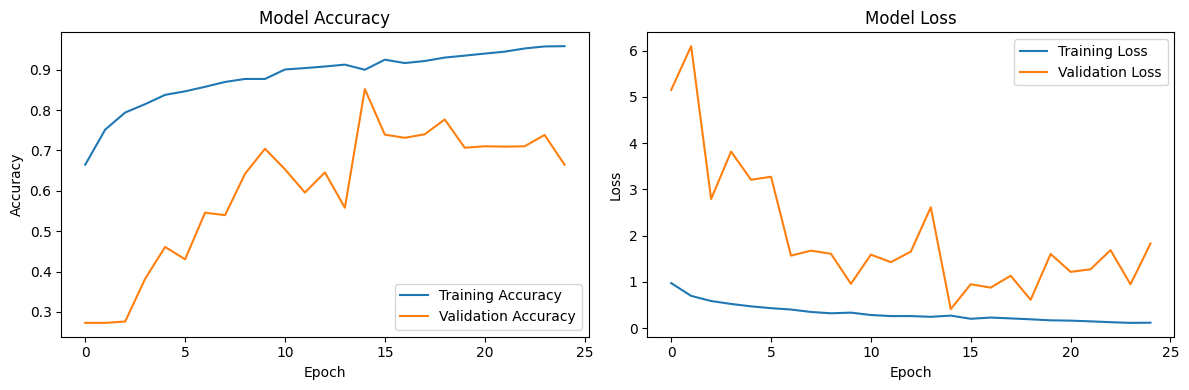

Models saved to models
Calculating anomaly scores for normal data...


100%|██████████| 1595/1595 [01:02<00:00, 25.52it/s]


Anomaly detection threshold set to: 2.629132843017578
Evaluating notumor images...


100%|██████████| 405/405 [00:39<00:00, 10.29it/s]


Evaluating glioma images...


...

Evaluating meningioma images...


100%|██████████| 306/306 [00:30<00:00, 10.15it/s]


Evaluating pituitary images...


100%|██████████| 300/300 [00:29<00:00, 10.10it/s]



Classification Report:
              precision    recall  f1-score   support

      glioma       0.84      0.57      0.68       300
  meningioma       0.64      0.87      0.74       306
     notumor       0.97      0.82      0.89       405
   pituitary       0.81      0.95      0.88       300

    accuracy                           0.80      1311
   macro avg       0.81      0.80      0.79      1311
weighted avg       0.83      0.80      0.80      1311



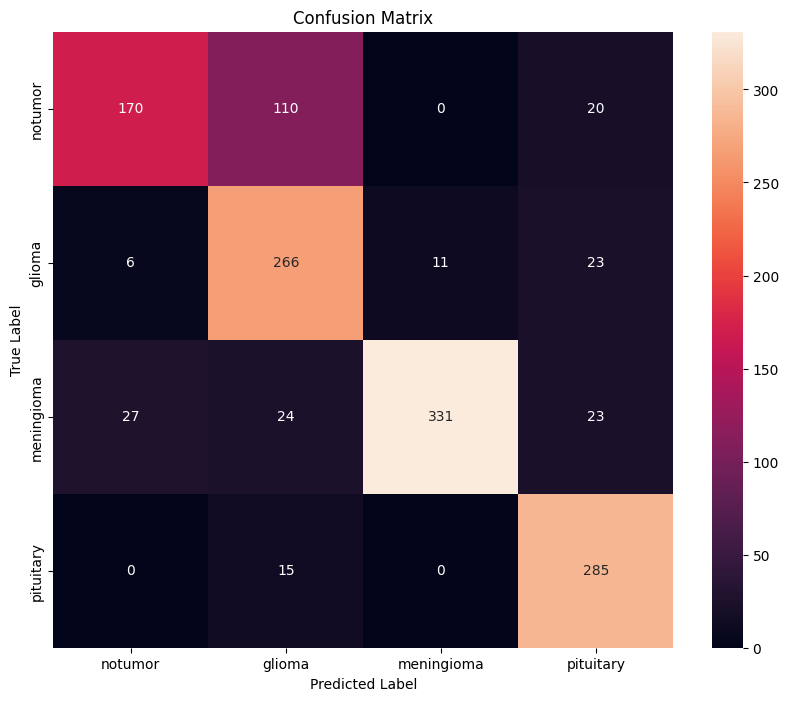

Evaluation completed successfully


In [4]:
if __name__ == '__main__':
    
    generator_path = "/kaggle/input/braingan/generator_epoch_9000.h5"
    discriminator_path = "/kaggle/input/braingan/discriminator_epoch_9000.h5"
    train_data_path = '/kaggle/input/brain-tumor-mri-dataset/Training'
    test_data_path = '/kaggle/input/brain-tumor-mri-dataset/Testing'
    normal_data_path = '/kaggle/input/brain-tumor-mri-dataset/Training/notumor'
    save_dir = '/kaggle/working'
    
    detector = train_detector(
        train_data_path=train_data_path,
        generator_path=generator_path,
        discriminator_path=discriminator_path,
        save_dir='models'
    )
    
    if detector is not None:
        
        detector.set_threshold(normal_data_path)
        
        
        results = evaluate_detector(detector, test_data_path)
        
        if results is not None:
            print("Evaluation completed successfully")